In [1]:
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path
from cartopy import crs as ccrs # Cartography library
import geopy.distance
import re
import pandas as pd
import cartopy.feature as cfeature
import matplotlib.patches as patches
import yaml
from scipy.spatial.distance import cdist
from matplotlib.dates import DateFormatter, MinuteLocator

In [2]:
### Link of the data
root = "ipfs://QmTSoNnvXX9bzu5SgVHeP7hVCuqJKFAkjk21LvzzCSGz9p"

In [38]:
def calculate_u_v(ds):
    # Convert wind speed and direction to u and v components
    wspd = ds['wspd']
    wdir = ds['wdir']
    
    # Convert wind direction from degrees to radians
    wdir_rad = np.deg2rad(wdir)
    
    # Calculate u and v components
    u = -wspd * np.sin(wdir_rad)  # u component (east-west)
    v = -wspd * np.cos(wdir_rad)  # v component (north-south)
    
    return u, v

In [3]:
def find_closest_grid_point(target_lon, target_lat, lon_array, lat_array,n_closest=4):
    """
    Find the closest grid point in the dataset to the given lon/lat.
    """
    targets_coords = np.radians([target_lat, target_lon])
    coords = np.column_stack([np.radians(lat_array), np.radians(lon_array)])

    ### calculate haversine distances

    def haversine_distance(coord1, coord2):
        lat1, lon1 = coord1
        lat2, lon2 = coord2
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        return 2 * np.arcsin(np.sqrt(a))
    
    #return targets_coords, coords
    distances = cdist([targets_coords], coords, metric=haversine_distance)[0]
    closest_indices = np.argsort(distances)[:n_closest]

    return closest_indices, distances[closest_indices]

In [4]:
def match_adcp_xband_ctd(xband, adcp, ctd_stations,dship):
    """
    Match ADCP and X-band data based on CTD stations.
    """
    adcp_u_list = []
    adcp_v_list = []
    xband_u_list = []
    xband_v_list = []
    heading_list = []

    for id in ctd_stations.index:
        time_slice = [stations_adcp.iloc[id]['start'], stations_adcp.iloc[id]['end']]
        ds_xband_cut = xband.where((xband.time >= np.datetime64(time_slice[0])) \
                                    & (xband.time <= np.datetime64(time_slice[1])), drop=True)
        times_xband_cut = np.unique(ds_xband_cut.time)
        for times_id in times_xband_cut:
            ds_xband_temp = ds_xband_cut.where(ds_xband_cut.time == times_id, drop=True)
            nearest_adcp = adcp.sel(time=times_id, method='nearest',tolerance='10min')
            nearest_dship = dship.sel(time=times_id, method='nearest',tolerance='10min')
            if ds_xband_temp.time.size > 0 and nearest_adcp.time.size > 0:
                points = find_closest_grid_point(
                    target_lon = nearest_adcp.LONGITUDE.values,
                    target_lat = nearest_adcp.LATITUDE.values,
                    lon_array = ds_xband_temp.longitude.values,
                    lat_array = ds_xband_temp.latitude.values,
                    n_closest=4)[0]
                adcp_u_list.append(nearest_adcp.sel(DEPTH=17).U.values)
                adcp_v_list.append(nearest_adcp.sel(DEPTH=17).V.values)
                heading_list.append(nearest_dship.ship_heading.values)
                xband_u_list.append(ds_xband_temp.isel(measurement=points).eastward_sea_water_velocity.mean().values)
                xband_v_list.append(ds_xband_temp.isel(measurement=points).northward_sea_water_velocity.mean().values)
    return np.array(adcp_u_list), np.array(adcp_v_list), np.array(xband_u_list), np.array(xband_v_list), np.array(heading_list)


In [5]:
def match_adcp_xband_movement(xband, adcp, dship, time_slice, ship_speed_threshold=4.5):
    """
    Match ADCP and X-band data based on ship movement.
    """
    adcp_u_list = []
    adcp_v_list = []
    xband_u_list = []
    xband_v_list = []
    heading_list = []
    time_list = []

    ds_dship_stage = dship.sel(time=slice(time_slice[0], time_slice[1]))
    ds_adcp_stage = adcp.sel(time=slice(time_slice[0], time_slice[1]),DEPTH=17)
    xband_radar_stage = xband.where(
        (xband.time>= np.datetime64(time_slice[0])) & \
         (xband.time<= np.datetime64(time_slice[1])),drop=True)
    
    times_xband_stage = np.unique(xband_radar_stage.time)
    ### find nearest time in adcp and xband
    for times_id in times_xband_stage:
        nearest_adcp = ds_adcp_stage.sel(time=times_id, method='nearest',tolerance='10min')
        nearest_dship = ds_dship_stage.sel(time=times_id, method='nearest',tolerance='10min')
        ds_xband_temp = xband_radar_stage.where(xband_radar_stage.time == times_id, drop=True)

        ### only consider when ship speed is above threshold
        if (nearest_dship.ship_speed.values >= ship_speed_threshold) and \
           (ds_xband_temp.time.size > 96) and (nearest_adcp.time.size > 0):
            points = find_closest_grid_point(
                target_lon = nearest_adcp.LONGITUDE.values,
                target_lat = nearest_adcp.LATITUDE.values,
                lon_array = ds_xband_temp.longitude.values,
                lat_array = ds_xband_temp.latitude.values,
                n_closest=8)[0]
            adcp_u_list.append(nearest_adcp.U.values)
            adcp_v_list.append(nearest_adcp.V.values)
            xband_u_list.append(ds_xband_temp.isel(measurement=points).eastward_sea_water_velocity.mean().values)
            xband_v_list.append(ds_xband_temp.isel(measurement=points).northward_sea_water_velocity.mean().values)
            heading_list.append(nearest_dship.ship_heading.values)
            time_list.append(nearest_adcp.time.values)
    return np.array(adcp_u_list), np.array(adcp_v_list), np.array(xband_u_list), np.array(xband_v_list), np.array(heading_list), time_list

In [147]:
### Calling radiosondes from METEOR
ds_adcp_75= xr.open_dataset(
    f"{root}/ADCP/met_203_vmadcp_75khz.zarr",engine="zarr").rename({"TIME":"time"})

ds_xband_radar= xr.open_dataset(
    f"{root}/Radar_Derived_Currents_M203.zarr",engine="zarr")

ds_dship= xr.open_dataset(
    f"{root}/DShip.zarr",engine="zarr")

ds_sea_snake= xr.open_dataset(
    f"{root}/SeaSnake/met_203_1_SeaSnake.zarr",engine="zarr")

dset_ctd = xr.open_dataset(f"{root}/CTD.zarr",engine="zarr")

dset_ctd_new = dset_ctd.assign_coords({'SOUNDING':dset_ctd.TIME.values}) 

ds_abacus = xr.open_dataset(f"{root}/WindLidar-Abacus/v1.0.zarr",engine="zarr")


In [101]:
root_radio = 'ipfs://QmSUUUPcGcpwdJJCVDGPGYksLsqkWbfh6d6xFcTk2Qu7Zf'
dset_radio = xr.open_dataset(f"{root_radio}/RAPSODI_RS_ORCESTRA_level2.zarr",engine="zarr")
dset_rad_meteor= dset_radio.where((dset_radio.platform=='RV_Meteor') & (dset_radio.ascent_flag==0),drop=True)

In [40]:
u_wind, v_wind = calculate_u_v(ds_dship)

(150.0, 10.0)

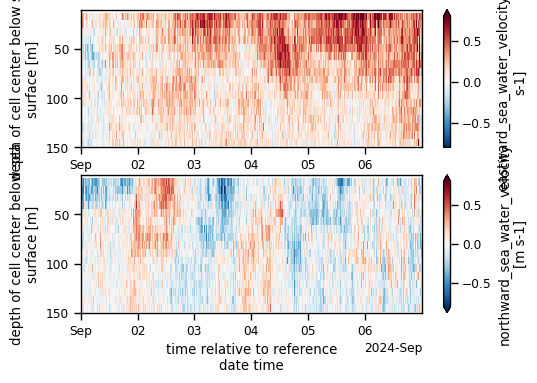

In [61]:
sns.set_context("paper")
adcp_data_u = ds_adcp_75.U.sel(time=slice("2024-09-01","2024-09-06"),DEPTH=slice(0,150))
adcp_data_v = ds_adcp_75.V.sel(time=slice("2024-09-01","2024-09-06"),DEPTH=slice(0,150))
fig = plt.figure(figsize=(14/2.54,10/2.54),facecolor='white')
#ax1=fig.add_axes([0.15,-0.08,0.3,0.02])
ax= fig.add_subplot(211)
(adcp_data_u).plot(ax=ax,add_colorbar=True,vmin=-0.8,vmax=0.8,cmap='RdBu_r')
ax.set_ylim([150,10])
ax= fig.add_subplot(212)
(adcp_data_v).plot(ax=ax,add_colorbar=True,vmin=-0.8,vmax=0.8,cmap='RdBu_r')
ax.set_ylim([150,10])

(150.0, 10.0)

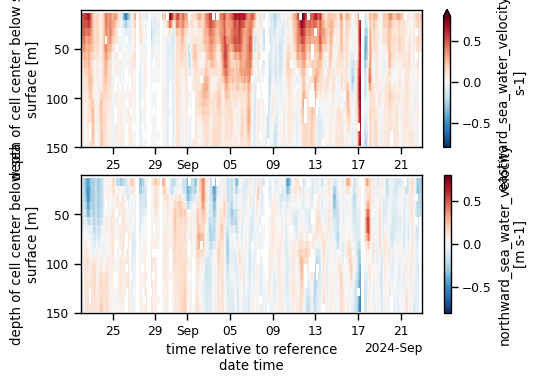

In [146]:
adcp_data_u_low = ds_adcp_75.U.rolling(time=60*6,center=True).mean().sel(time=slice("2024-08-22","2024-09-22"),DEPTH=slice(0,150))
adcp_data_v_low = ds_adcp_75.V.rolling(time=60*6,center=True).mean().sel(time=slice("2024-08-22","2024-09-22"),DEPTH=slice(0,150))
fig = plt.figure(figsize=(14/2.54,10/2.54),facecolor='white')
#ax1=fig.add_axes([0.15,-0.08,0.3,0.02])
ax= fig.add_subplot(211)
(adcp_data_u_low).plot(ax=ax,add_colorbar=True,vmin=-0.8,vmax=0.8,cmap='RdBu_r')  
ax.set_ylim([150,10])
ax= fig.add_subplot(212)
(adcp_data_v_low).plot(ax=ax,add_colorbar=True,vmin=-0.8,vmax=0.8,cmap='RdBu_r')  
ax.set_ylim([150,10])

(150.0, 10.0)

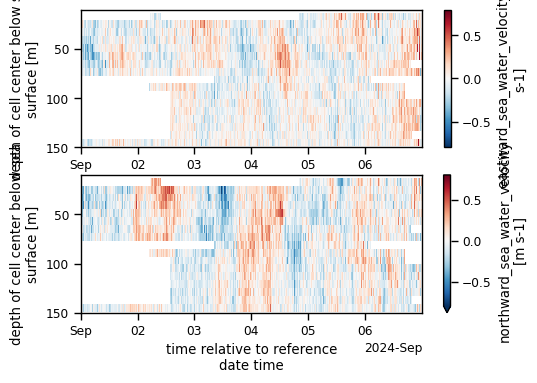

In [129]:
adcp_data_u_high = ds_adcp_75.U - ds_adcp_75.U.rolling(time=60*48,center=True).mean().sel(time=slice("2024-09-01","2024-09-06"),DEPTH=slice(0,150))
adcp_data_v_high = ds_adcp_75.V - ds_adcp_75.V.rolling(time=60*48,center=True).mean().sel(time=slice("2024-09-01","2024-09-06"),DEPTH=slice(0,150))
fig = plt.figure(figsize=(14/2.54,10/2.54),facecolor='white')
#ax1=fig.add_axes([0.15,-0.08,0.3,0.02])
ax= fig.add_subplot(211)
(adcp_data_u_high).plot(ax=ax,add_colorbar=True,vmin=-0.8,vmax=0.8,cmap='RdBu_r')  
ax.set_ylim([150,10])
ax= fig.add_subplot(212)
(adcp_data_v_high).plot(ax=ax,add_colorbar=True,vmin=-0.8,vmax=0.8,cmap='RdBu_r')  
ax.set_ylim([150,10])